In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.special import softmax

(0.0, 1.0)

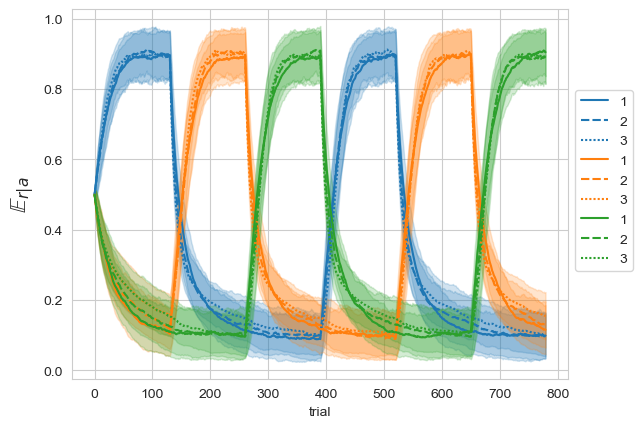

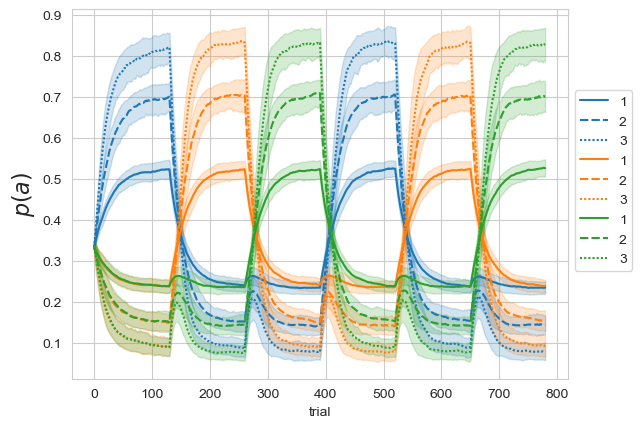

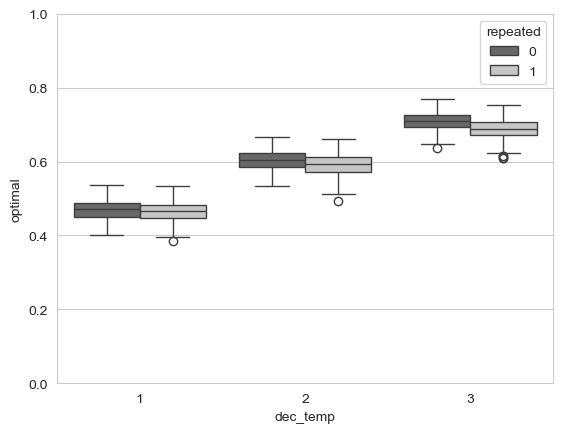

In [46]:
nb = 3
nr = 2
nc = 3

trials_per_context = 130
training_regime = np.tile(np.arange(nc).repeat(trials_per_context),2)
n_trials = training_regime.size
n_sims = 200
dec_temps  = [1,2,3]

# bandit reward contingencies
p = 0.9
p_reward = np.ones([nb,nb])*(1-p) + np.eye(nb)*(p-1+p)
p_no_reward = np.ones([nb,nb])*p - np.eye(nb)*(p-1+p)
reward_contingencies = np.stack([p_no_reward, p_reward],axis=0)
# print(reward_contingencies[:,:,0])


alpha = 0.1                                       # learning rate
epsilon = 0.1                                     # e-greedy decision rule
Q_action = np.ones([n_sims, n_trials+1,nb])*0.5   # action values
P_action = np.zeros([n_sims, n_trials+1,nb])      # action probabilities
P_action[:,0,:] = 1/nb

rewards = np.zeros([n_sims, n_trials])
actions = np.zeros([n_sims, n_trials])

dfs = []
# run sims
for dec_temp in dec_temps:
	for agent in range(n_sims):
		for t in range(n_trials):

			# e-greedy action selection, if not argmax choice than any other one with equal probability
			# if np.random.uniform() < epsilon:
			#     all_actions = np.arange(nb) 
			#     all_actions = all_actions[all_actions != np.argmax(P_action[agent,t])]
			#     # Q_reduced = Q_action[agent,t,all_actions]'
			#     # P_reduced = softmax(Q_reduced)
			#     # action = np.random.choice(nb-1, p=P_reduced)
			#     np.random.shuffle(all_actions)
			#     action = all_actions[0]
			#     print(agent,t,"greedy action",action)
			# else:
			#     action = np.argmax(P_action[agent,t])
			action = np.random.choice(nb, p=P_action[agent,t])
			context = training_regime[t]
			reward = np.random.choice(nr, p=reward_contingencies[:,action,context])
			
			rewards[agent,t] = reward
			actions[agent,t] = action

			Q_action[agent,t+1] = Q_action[agent,t] + alpha*(reward - Q_action[agent,t])*np.eye(nb)[action]
			P_action[agent,t+1] = softmax(dec_temp*Q_action[agent,t+1])

		df_dict = {
			"agent" : np.array([agent]).repeat(n_trials),
			"context": np.tile(np.arange(nc).repeat(trials_per_context),2),
			"trial" : np.arange(n_trials),
			"actions" : actions[agent],
			"reward" : rewards[agent],
			"dec_temp": np.array([dec_temp]*n_trials),
			"repeated": np.arange(2).repeat(n_trials//2)
		}

		for bandit in range(nb):
			df_dict[f"q_{bandit}"] = Q_action[agent,:-1,bandit]#.reshape(n_sims*n_trials)
		for bandit in range(nb):
			df_dict[f"p_{bandit}"] = P_action[agent,:-1,bandit]#.reshape(n_sims*n_trials)		
		dfs.append(pd.DataFrame(df_dict))

df = pd.concat(dfs)

sns.set_style("whitegrid")

plt.figure()
for ni in range(nc):
	g = sns.lineplot(data=df,x="trial",y=f"q_{ni}", errorbar="sd",style="dec_temp")
	g.set_ylabel(r"$\mathbb{E}_{r|a}$", fontsize=16)
handles, labels = g.get_legend_handles_labels()
g.legend(handles=handles, labels=labels, bbox_to_anchor=(1,0.8))

plt.figure()
for ni in range(nc):
	g = sns.lineplot(data=df,x="trial",y=f"p_{ni}", errorbar="sd",style="dec_temp")
	g.set_ylabel(r"$p(a)$", fontsize=16)
handles, labels = g.get_legend_handles_labels()
g.legend(handles=handles, labels=labels, bbox_to_anchor=(1,0.8))


plt.figure()
df["optimal"] = df["context"] == df["actions"]
g = sns.boxplot(data=df.groupby(by=["dec_temp","agent","repeated"])["optimal"].mean().reset_index(), y="optimal", x="dec_temp", hue="repeated",palette="Greys_r")
g.set_ylim([0,1])

In [ ]:
from scipy.stats import ttest_rel

df_test = df.groupby(by=["dec_temp","agent","repeated"])["optimal"].mean().reset_index().set_index(["dec_temp","agent","repeated"])
ttest_rel(df_test.loc[1,:,0],df_test.loc[1,:,1])


TtestResult(statistic=array([2.11720634]), pvalue=array([0.03548426]), df=array([199]))

In [ ]:
ttest_rel(df_test.loc[3,:,0],df_test.loc[3,:,1])

TtestResult(statistic=array([8.09231907]), pvalue=array([5.69683233e-14]), df=array([199]))

In [97]:
df_test.reset_index(inplace=True)
df_test["model"] = "MFRL"
df_test.to_csv("mfrl_data.csv",index=False)

,level_0,index,dec_temp,agent,repeated,optimal,model
0,0.0,0.0,1,0,0,0.482051,MFRL
1,1.0,1.0,1,0,1,0.476923,MFRL
2,2.0,2.0,1,1,0,0.438462,MFRL
3,3.0,3.0,1,1,1,0.484615,MFRL
4,4.0,4.0,1,2,0,0.458974,MFRL


C:\Users\ivsi289a\AppData\Local\Temp\ipykernel_25760\997087029.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=["MFRL","NP-BCC"], fontsize=14)


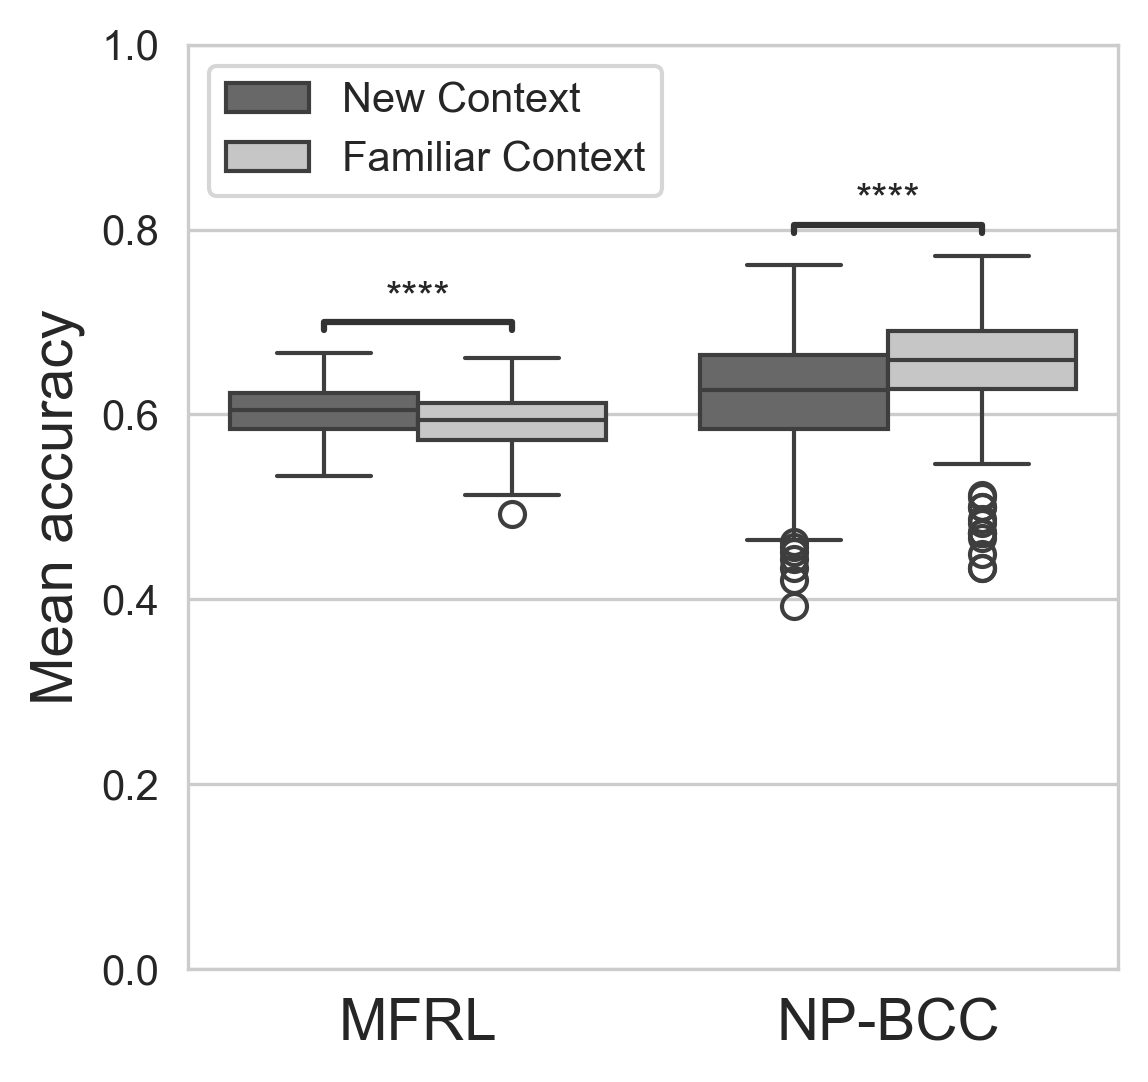

In [130]:
from statannotations.Annotator import Annotator

mf = pd.read_csv("mfrl_data.csv")
bcc = pd.read_csv("bcc_data.csv")
df_new = pd.concat([mf.query("dec_temp == 2"),bcc])

fig, ax = plt.subplots(1,1,figsize=(4,4),dpi=300)
sns.boxplot(ax=ax, data=df_new, x="model", y="optimal", hue="repeated",palette="Greys_r")

unique_models = sorted(df_new["model"].unique())
box_pairs = [((model, 0), (model, 1)) for model in unique_models]
# Create the annotator
annotator = Annotator(ax, pairs=box_pairs, data=df_new, x="model", y="optimal", hue="repeated")
annotator.configure(test="Mann-Whitney", text_format="star", loc="inside", comparisons_correction=None, verbose=0)
_,results = annotator.apply_and_annotate()       

ax.set_ylim([0,1])
ax.set_ylabel("Mean accuracy", fontsize=14)
handles, labels = g.get_legend_handles_labels()
ax.legend(handles=handles,labels=["New Context","Familiar Context"])
ax.set_xlabel("")
ax.set_xticklabels(labels=["MFRL","NP-BCC"], fontsize=14)

fig.savefig("supp_fig_1.png")